Name:Wafa Karim Khan

Msc(Data science & Big Data Analytics)

College: B.K Birla College of Arts, Science and Commerce kalyan.

Task3:Housing Price Prediction - Linear Regression vs. Random Forest

Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


Load the Dataset

In [2]:
# Load the dataset

data = pd.read_csv('Housing.csv')

Data Exploration and Preprocessing

In [20]:
# Display the first few rows of the dataset
print(data.head())


print("Shape of the data:", data.shape)


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
Shape of the data: (545, 13)


In [4]:
# Check for missing values
print(data.isnull().sum())


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
# Check the data types of each column
print(data.dtypes)

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [6]:
# Handle categorical variables
data_encoded = pd.get_dummies(data)


In [7]:
# Check the columns and their datatype in the data_encoded DataFrame
print(data_encoded.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_no                         bool
mainroad_yes                        bool
guestroom_no                        bool
guestroom_yes                       bool
basement_no                         bool
basement_yes                        bool
hotwaterheating_no                  bool
hotwaterheating_yes                 bool
airconditioning_no                  bool
airconditioning_yes                 bool
prefarea_no                         bool
prefarea_yes                        bool
furnishingstatus_furnished          bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [8]:
print(data_encoded)

        price  area  bedrooms  bathrooms  stories  parking  mainroad_no  \
0    13300000  7420         4          2        3        2        False   
1    12250000  8960         4          4        4        3        False   
2    12250000  9960         3          2        2        2        False   
3    12215000  7500         4          2        2        3        False   
4    11410000  7420         4          1        2        2        False   
..        ...   ...       ...        ...      ...      ...          ...   
540   1820000  3000         2          1        1        2        False   
541   1767150  2400         3          1        1        0         True   
542   1750000  3620         2          1        1        0        False   
543   1750000  2910         3          1        1        0         True   
544   1750000  3850         3          1        2        0        False   

     mainroad_yes  guestroom_no  guestroom_yes  ...  basement_yes  \
0            True          Tru

In [9]:
# Split features and target variable
X = data_encoded.drop('price', axis=1)
y = data_encoded['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#random_state=42:ensuring that the same data points are assigned each time when the code is executed.

# Standardize features :
#(Standardization helps algorithms converge faster and prevents features with larger scales 
# from dominating those with smaller scales during the training process.)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  #calculates the mean and standard deviation of each feature in the training set.
X_test_scaled = scaler.transform(X_test) # does the same for testing


Train Linear Regression Model

In [10]:
# Initialize and train the linear regression model
lr_model = LinearRegression() #create a linear regression model
lr_model.fit(X_train_scaled, y_train) #fit() method to train the model using the training data 

# Predict on the test set
y_pred_lr = lr_model.predict(X_test_scaled) #make predictions on the test set 


Train Random Forest Model

In [11]:
# Initialize and train the random forest model
rf_model = RandomForestRegressor(random_state=42) #train the model using the training data
rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test_scaled) #make predictions on the test set 


Model Evaluation

In [12]:
# Evaluate linear regression model
mse_lr = mean_squared_error(y_test, y_pred_lr) #It measures the average squared difference between actual and predicted values.
r2_lr = r2_score(y_test, y_pred_lr) #measures proportion of the variance in the DV that is predictable from the IV. 

print("Linear Regression Model:")
print("Mean Squared Error:", mse_lr)
print("R-squared:", r2_lr)

# Evaluate random forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Model:")
print("Mean Squared Error:", mse_rf)
print("R-squared:", r2_rf)


Linear Regression Model:
Mean Squared Error: 1772007011927.6953
R-squared: 0.6494247927004512

Random Forest Model:
Mean Squared Error: 1971006449235.8137
R-squared: 0.610054593532394


The Linear Regression model has a lower Mean Squared Error (MSE) a higher R-squared value compared to the Random Forest model.

Result:The Linear Regression model appears to be a better fit for the data.

*Visualizations*

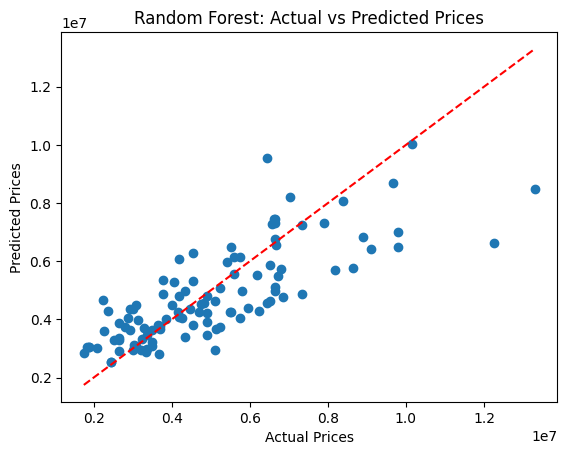

In [13]:
# Scatter plot comparing actual vs predicted prices for random forest
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Diagonal line
#The diagonal line indicates where actual prices equal predicted prices.
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.show()


Observations:The data points were scattered around the line but There are data points above and below the diagonal line. 
Points above the line represent houses where the model underpredicted the price (predicted price lower than actual price) and vice versa.

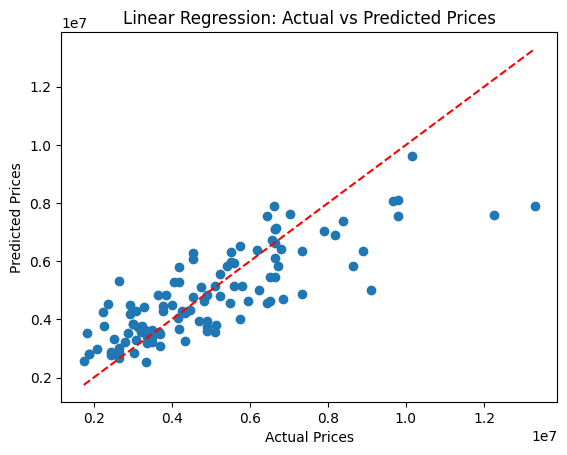

In [14]:
# Scatter plot comparing actual vs predicted prices for linear regression
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Diagonal line
#The diagonal line indicates where actual prices equal predicted prices.
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.show()
